# Backtest casado em horizonte + *nowcast* da carteira de crédito
### Estratégia de avaliação de modelos de risco de crédito ligada à informação mais recente

**Contexto.** O backtest tradicional (GINI/KS, PD obs×pred, PSI, VOP, saldo) é estruturalmente **velho**: para avaliar um PD-12m você precisa de 12 meses de janela mais a definição de *default* (90 DPD). Quando o modelo é reavaliado em M-2, a leitura formal sempre olha safras que **maturaram há mais de um ano**.

Este notebook implementa uma estratégia em **três eixos temporais** que mantém o backtest rigoroso onde ele é exigido (provisão/ECL) e adiciona camadas **coincidente** e **líder** que leem o estado *vivo* da carteira:

| Eixo | Pergunta | Métricas | Defasagem |
|---|---|---|---|
| **Safra** (origination) | A originação está piorando? | curva de vintage observada × implícita | maturação |
| **Calendário** (coincidente) | O que está acontecendo *agora*? | roll-rate, *overs*, PSI/CSI | fechamento (M-1/M-2) |
| **Maturidade** (outcome) | O backtest formal fecha? | GINI/KS, PD obs×pred | maturação plena |

A ponte entre o sinal fresco e o veredito final é um **modelo de convergência** (trata a métrica provisória como um *nowcast* que será revisado, com banda de incerteza), e o indicador de fechamento é o **EWI**: o *gap* entre PD previsto e PD *nowcastado* por faixa de score.

> ⚠️ **Governança.** A camada de *nowcast* é **gestão / early-warning**, não substitui o backtest formal que alimenta provisão sob CMN 4.966 / IFRS 9. Ela antecipa e direciona; o oficial permanece no eixo de maturidade. Todos os dados aqui são **simulados**.


## 0. Setup e parâmetros

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from numpy.linalg import matrix_power
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

plt.rcParams.update({
    "figure.figsize": (8.2, 4.4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "grid.linewidth": .6,
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold",
})
INK="#16324f"; ACC="#c0392b"; ACC2="#2a7f62"; AMB="#d98c00"
rng = np.random.default_rng(42)

H        = 12                       # horizonte de avaliacao (MOB)
N_SAFRAS = 24                       # 2024-01 .. 2025-12
N_PER    = 1500                     # contratos por safra
N_STATES = 5                        # 0=Em dia 1=DPD30 2=DPD60 3=DPD90 4=Default
ASOF     = pd.Timestamp("2025-12-31")
safra_dates = pd.date_range("2024-01-01", periods=N_SAFRAS, freq="MS")
ESTADOS = ["Em dia","DPD30","DPD60","DPD90","Default"]
print("As-of:", ASOF.date(), "| safras:", N_SAFRAS, "| horizonte:", H, "MOB")

As-of: 2025-12-31 | safras: 24 | horizonte: 12 MOB


## 1. Simulação da carteira (multi-estado mensal, com censura à direita)

Cada contrato evolui mês a mês por uma cadeia de estados de atraso. As intensidades de transição dependem de um **risco latente** $r\in[0,1]$ do contrato (que também gera o *score* de originação, "alto = bom"). Safras mais recentes recebem um **drift** que piora levemente a originação — é o sinal que queremos que a estratégia capture **antes** de maturar.

A **censura à direita** é o ponto central: para a safra de 2025-11 só observamos ~1 MOB em 2025-12. Essas safras entram **incompletas** em todas as visões coincidentes/líderes, e são exatamente as que o backtest tradicional não consegue ler.

In [4]:
def build_contracts():
    rows = []
    for si, sdate in enumerate(safra_dates):
        r = rng.beta(2.0, 5.0, N_PER)                       # risco latente
        drift = 0.06 * (si - N_SAFRAS/2) / N_SAFRAS          # safras novas piores
        r_eff = np.clip(r + drift, 0.001, 0.999)
        score = np.clip(1000 - 1000*r + rng.normal(0, 40, N_PER), 0, 1000)
        rows.append(pd.DataFrame({"safra_idx": si, "orig_date": sdate,
                                  "r": r_eff, "score": score}))
    c = pd.concat(rows, ignore_index=True)
    c["id"] = np.arange(len(c))
    mob_obs = ((ASOF.year-c.orig_date.dt.year)*12 + (ASOF.month-c.orig_date.dt.month))
    c["mob_max"] = np.clip(mob_obs, 0, H).astype(int)        # MOB observavel (censura)
    return c

def trans_probs(state, r):
    n = len(r); P = np.zeros((n, N_STATES))
    if state == 0:
        p = np.clip(0.015+0.12*r, .005,.6); P[:,1]=p; P[:,0]=1-p
    elif state == 1:
        w=np.clip(0.25+0.50*r,.05,.9); cu=np.minimum(np.clip(0.55-0.45*r,.02,.95),1-w-1e-6)
        P[:,2]=w; P[:,0]=cu; P[:,1]=1-w-cu
    elif state == 2:
        w=np.clip(0.35+0.45*r,.05,.9); cu=np.minimum(np.clip(0.35-0.25*r,.02,.95),1-w-1e-6)
        P[:,3]=w; P[:,1]=cu; P[:,2]=1-w-cu
    elif state == 3:
        wd=np.clip(0.45+0.40*r,.05,.95); cu=np.minimum(np.clip(0.25-0.20*r,.01,.9),1-wd-1e-6)
        P[:,4]=wd; P[:,2]=cu; P[:,3]=1-wd-cu
    else:
        P[:,4]=1.0
    return P

def simulate_paths(c):
    n=len(c); r=c.r.to_numpy(); paths=np.zeros((n,H+1),dtype=np.int8)
    for m in range(1,H+1):
        cur=paths[:,m-1]; nxt=cur.copy()
        for s in range(N_STATES):
            mask=cur==s
            if not mask.any(): continue
            cum=np.cumsum(trans_probs(s,r[mask]),axis=1)
            draws=rng.random(mask.sum())
            nxt[mask]=(draws[:,None]<cum).argmax(axis=1)
        paths[:,m]=nxt
    return paths

contracts = build_contracts()
paths     = simulate_paths(contracts)
n         = len(contracts)
mob_max   = contracts.mob_max.to_numpy()
print(f"{n:,} contratos simulados | trajetorias shape={paths.shape}")

36,000 contratos simulados | trajetorias shape=(36000, 13)


**Derivados observáveis** — sempre respeitando a censura (`mob_max`): default/ever30 acumulados até MOB *k*, estado vivo atual, e flag de safra madura.

In [5]:
def default_by_k(k):
    return (paths[:,:k+1]==4).any(axis=1), mob_max>=k
def ever30_by_k(k):
    return (paths[:,:k+1]>=1).any(axis=1), mob_max>=k

cur_state = paths[np.arange(n), mob_max]            # estado no MOB observavel mais recente
contracts["cur_state"] = cur_state
contracts["mature"]    = mob_max>=H
def_term, _            = default_by_k(H)
contracts["default12"] = def_term
contracts["band"]      = pd.qcut(contracts.score, 10, labels=False, duplicates="drop")

n_mat = contracts.groupby("safra_idx").mature.any().sum()
print(f"Safras maduras (MOB>={H}): {n_mat} de {N_SAFRAS}")
print(f"PD12 observada (maduras): {contracts.loc[contracts.mature,'default12'].mean():.4f}")

Safras maduras (MOB>=12): 12 de 24
PD12 observada (maduras): 0.1106


**Modelo preditivo** — uma logística *score→default* ajustada **apenas nas safras maduras**. Por construção ela não enxerga o drift recente: é isso que cria a defasagem que a estratégia precisa cobrir.

In [6]:
mat = contracts[contracts.mature].copy()
lr  = LogisticRegression().fit(mat[["score"]].to_numpy()/1000., mat.default12.astype(int))
contracts["pd_pred"] = lr.predict_proba(contracts[["score"]].to_numpy()/1000.)[:,1]
mat = contracts[contracts.mature].copy()            # refaz slice c/ pd_pred
print(f"PD_pred media: {contracts.pd_pred.mean():.4f}")

PD_pred media: 0.1108


## 2. Eixo de maturidade — backtest tradicional (baseline)

A camada formal, sobre as safras maduras (M-2+): **discriminação** (GINI/KS) e **calibração** (PD obs×pred por faixa). É o veredito que alimenta provisão — e é o que a estratégia mantém intacto.

GINI=0.405 | KS=0.302


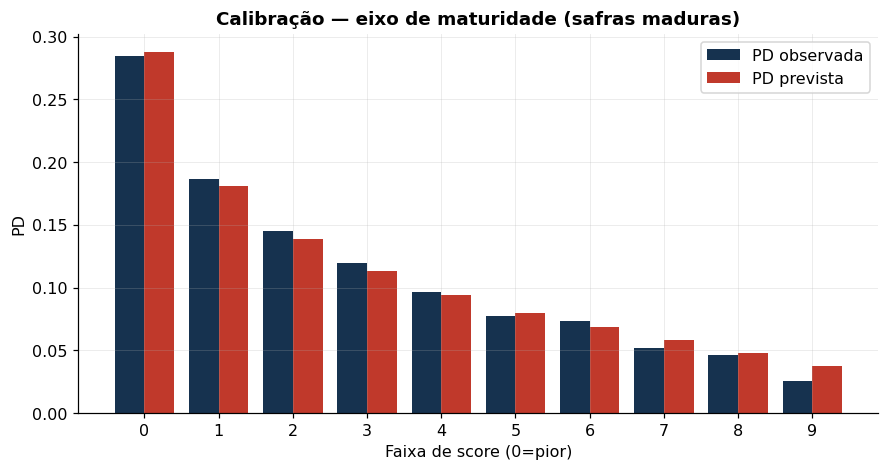

In [7]:
def gini(y,s):  return 2*roc_auc_score(y,s)-1
def ks_stat(y,s):
    o=np.argsort(s); y=np.asarray(y)[o]
    cb=np.cumsum(y)/max(y.sum(),1); cg=np.cumsum(1-y)/max((1-y).sum(),1)
    return np.max(np.abs(cb-cg))

g = gini(mat.default12, -mat.score); k = ks_stat(mat.default12.to_numpy(), -mat.score.to_numpy())
cal = mat.groupby("band").agg(pd_obs=("default12","mean"),
                              pd_pred=("pd_pred","mean"), n=("id","size"))
print(f"GINI={g:.3f} | KS={k:.3f}")

fig,ax=plt.subplots()
x=np.arange(len(cal))
ax.bar(x-.2, cal.pd_obs, .4, label="PD observada", color=INK)
ax.bar(x+.2, cal.pd_pred, .4, label="PD prevista", color=ACC)
ax.set_xlabel("Faixa de score (0=pior)"); ax.set_ylabel("PD"); ax.set_xticks(x)
ax.set_title("Calibração — eixo de maturidade (safras maduras)"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Eixo de safra — backtest casado em horizonte

Decompomos o PD-12m numa **estrutura a termo**: a curva de maturação $f(k)$ é a fração do *default* terminal que já materializou até o MOB $k$ (estimada nas maduras). Para uma safra fresca no MOB $k$:

$$\text{default acumulado implícito}(k) = \overline{PD}_{12}^{\text{prev}} \times f(k)
\qquad\text{vs}\qquad \text{default acumulado observado}(k).$$

Para $k$ pequeno isso dá **leitura imediata de calibração**; conforme a safra matura, converge para o backtest cheio. Se o observado descola do implícito numa safra nova, você viu a deterioração **antes** do default de 12m existir.

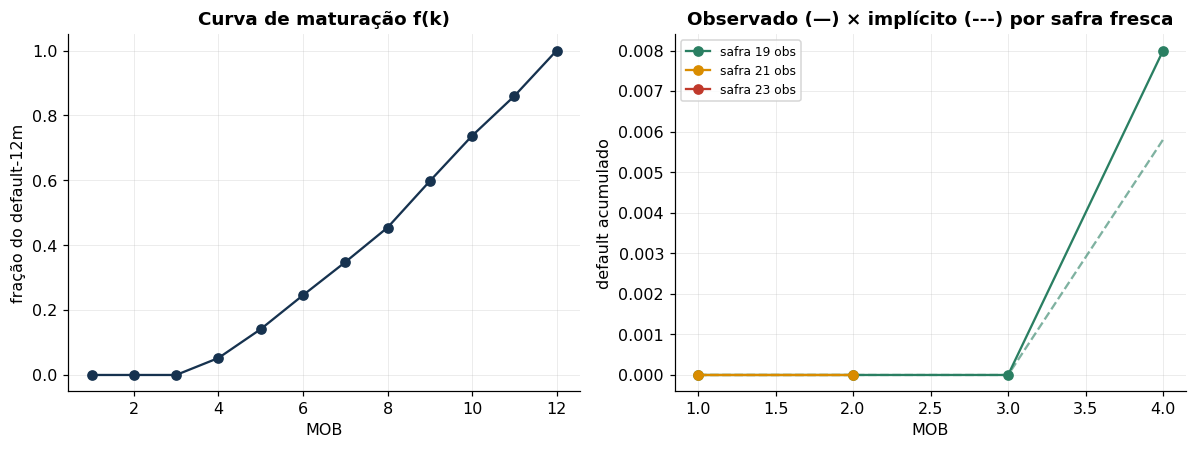

In [8]:
fk = np.array([default_by_k(kk)[0][contracts.mature.to_numpy()].mean() for kk in range(1,H+1)])
fk = fk/fk[-1]                                       # normaliza p/ 1 em MOB H

def horizon_match(safra_idx,k):
    m=(contracts.safra_idx==safra_idx).to_numpy()
    dk,obs=default_by_k(k); sel=m&obs
    return dk[sel].mean(), contracts.loc[m,"pd_pred"].mean()*fk[k-1]

fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.2))
a1.plot(range(1,H+1), fk, "o-", color=INK); a1.set_title("Curva de maturação f(k)")
a1.set_xlabel("MOB"); a1.set_ylabel("fração do default-12m")
for sidx,c_ in zip([19,21,23],[ACC2,AMB,ACC]):
    kmax=int(contracts.loc[contracts.safra_idx==sidx,"mob_max"].max())
    obs=[default_by_k(kk)[0][(contracts.safra_idx==sidx).to_numpy()&(default_by_k(kk)[1])].mean()
         for kk in range(1,kmax+1)]
    impl=[contracts.loc[contracts.safra_idx==sidx,"pd_pred"].mean()*fk[kk-1] for kk in range(1,kmax+1)]
    a2.plot(range(1,kmax+1),obs,"o-",color=c_,label=f"safra {sidx} obs")
    a2.plot(range(1,kmax+1),impl,"--",color=c_,alpha=.6)
a2.set_title("Observado (—) × implícito (---) por safra fresca")
a2.set_xlabel("MOB"); a2.set_ylabel("default acumulado"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Eixo de calendário — roll-rate (Markov) e *nowcast* do PD

A matriz de transição mensal $T$ é estimada das transições **calendário-recentes** entre os baldes de atraso. A partir do **estado vivo atual** de cada contrato, projetamos a probabilidade de *default* até o horizonte:

$$PD^{\text{nowcast}}_i = \big(T^{\,k_i}\big)_{\,s_i,\;\text{Default}},\qquad k_i = H - \text{MOB}_i.$$

Isso é o **PD nowcastado** — sem esperar maturar. Comparável diretamente ao PD previsto por faixa de score.

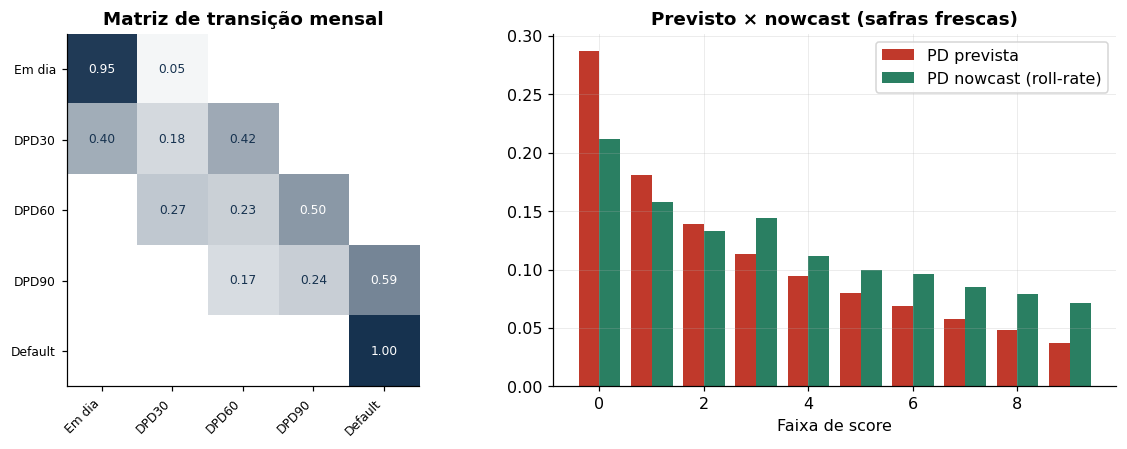

In [9]:
def estimate_transition(window=6):
    T=np.zeros((N_STATES,N_STATES))
    for ci in range(n):
        mm=mob_max[ci]
        for m in range(max(1,mm-window+1),mm+1):
            T[paths[ci,m-1],paths[ci,m]]+=1
    row=T.sum(1,keepdims=True); row[row==0]=1
    return T/row
Tm=estimate_transition()

def nowcast_pd(state,k):  return matrix_power(Tm,k)[state,4] if k>0 else float(state==4)

fresh=contracts[~contracts.mature].copy()
fresh["months_left"]=H-mob_max[~contracts.mature.to_numpy()]
fresh["pd_nowcast"]=[1.0 if s==4 else nowcast_pd(int(s),int(kl))
                     for s,kl in zip(fresh.cur_state,fresh.months_left)]

cmap=LinearSegmentedColormap.from_list("ink",["#ffffff",INK])
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.2))
im=a1.imshow(Tm,cmap=cmap,vmin=0,vmax=1)
a1.set_xticks(range(5)); a1.set_yticks(range(5))
a1.set_xticklabels(ESTADOS,rotation=45,ha="right",fontsize=8); a1.set_yticklabels(ESTADOS,fontsize=8)
a1.set_title("Matriz de transição mensal"); a1.grid(False)
for i in range(5):
    for j in range(5):
        if Tm[i,j]>=.01: a1.text(j,i,f"{Tm[i,j]:.2f}",ha="center",va="center",
                                 color="white" if Tm[i,j]>.5 else INK,fontsize=8)
nb_=fresh.groupby("band").agg(pd_pred=("pd_pred","mean"),pd_nowcast=("pd_nowcast","mean"))
x=np.arange(len(nb_))
a2.bar(x-.2,nb_.pd_pred,.4,label="PD prevista",color=ACC)
a2.bar(x+.2,nb_.pd_nowcast,.4,label="PD nowcast (roll-rate)",color=ACC2)
a2.set_title("Previsto × nowcast (safras frescas)"); a2.set_xlabel("Faixa de score"); a2.legend()
plt.tight_layout(); plt.show()

### 4.1 Conversão *over* → PD terminal

Empiricamente, $P(\text{default}_{12}\mid \text{estado}=s \text{ no MOB }k)$ estimado nas maduras. É o elo numérico que transforma o *over* fresco em **PD observada projetada**, e mostra como o poder preditivo do atraso decai com a maturidade.

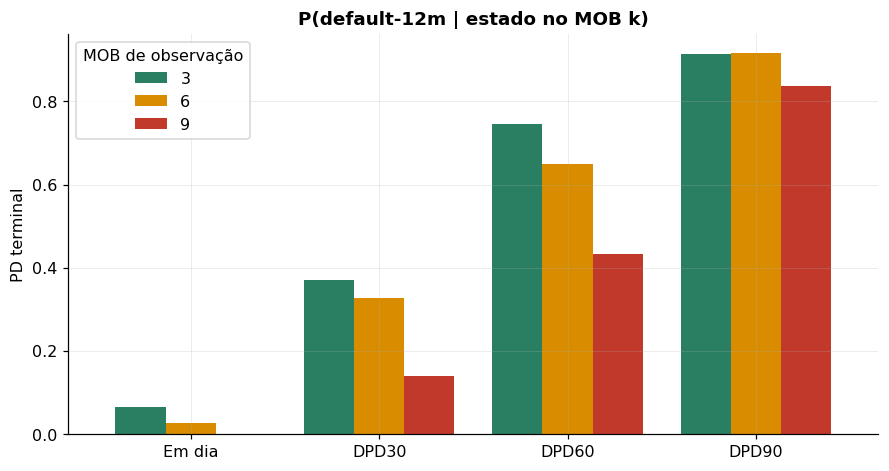

In [10]:
recs=[]
for kk in [3,6,9]:
    for s in range(4):
        sel=(mob_max>=H)&(paths[:,kk]==s)
        if sel.sum()>30: recs.append({"mob":kk,"estado":ESTADOS[s],"p_default":def_term[sel].mean()})
o2p=pd.DataFrame(recs).pivot(index="estado",columns="mob",values="p_default").reindex(ESTADOS[:4])

fig,ax=plt.subplots()
o2p.plot(kind="bar",ax=ax,color=[ACC2,AMB,ACC],width=.8)
ax.set_title("P(default-12m | estado no MOB k)"); ax.set_ylabel("PD terminal")
ax.set_xlabel(""); ax.legend(title="MOB de observação"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 5. Ponte de convergência (*nowcast* com revisão)

Tratamos a métrica provisória como um *nowcast* que **será revisado**, igual revisão de PIB. Para cada safra registramos o GINI **provisório** (contra a *proxy* `ever30@MOB6`) e, nas maduras, o GINI **final** (contra `default@MOB12`). Ajustamos $\text{final}\approx \beta_0+\beta_1\,\text{prov}$ com **banda** $\pm 2\sigma$. Para safras frescas só temos o provisório → projetamos o final **com intervalo**.

Quando o provisório de uma safra sai da banda histórica, é **regime novo** — não ruído de imaturidade. Isso protege do falso positivo ("safra nova parece ruim só porque é imatura") e do falso negativo.

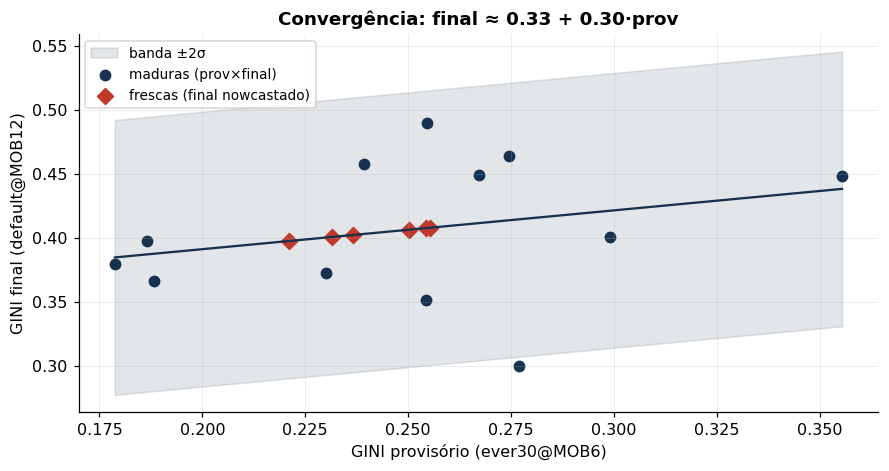

In [11]:
rows=[]
for si in range(N_SAFRAS):
    m=(contracts.safra_idx==si).to_numpy(); mm=int(contracts.loc[contracts.safra_idx==si,"mob_max"].max())
    if mm>=6:
        prov=gini(ever30_by_k(6)[0][m].astype(int), -contracts.loc[m,"score"])
        rec={"safra":si,"gini_prov":prov,"mob":mm}
        if mm>=H: rec["gini_final"]=gini(def_term[m].astype(int),-contracts.loc[m,"score"])
        rows.append(rec)
conv=pd.DataFrame(rows); cm=conv.dropna()
b1,b0=np.polyfit(cm.gini_prov,cm.gini_final,1)
sd=(cm.gini_final-(b0+b1*cm.gini_prov)).std()
frz=conv[conv.gini_final.isna()].copy(); frz["gini_nowcast"]=b0+b1*frz.gini_prov

fig,ax=plt.subplots()
xs=np.linspace(conv.gini_prov.min(),conv.gini_prov.max(),50)
ax.fill_between(xs,b0+b1*xs-2*sd,b0+b1*xs+2*sd,color=INK,alpha=.12,label="banda ±2σ")
ax.plot(xs,b0+b1*xs,color=INK,lw=1.5)
ax.scatter(cm.gini_prov,cm.gini_final,color=INK,s=45,label="maduras (prov×final)")
ax.scatter(frz.gini_prov,frz.gini_nowcast,color=ACC,marker="D",s=55,
           label="frescas (final nowcastado)")
ax.set_xlabel("GINI provisório (ever30@MOB6)"); ax.set_ylabel("GINI final (default@MOB12)")
ax.set_title(f"Convergência: final ≈ {b0:.2f} + {b1:.2f}·prov"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 6. EWI — *gap* entre PD previsto e PD *nowcastado* por faixa

O indicador que fecha o ciclo. Dispara **antes** do backtest oficial e aponta **onde** (qual faixa) o modelo descalibra:

$$\text{gap}(b) = \overline{PD^{\text{nowcast}}}(b) - \overline{PD^{\text{prev}}}(b).$$

Semáforo: 🟢 $\le 1$p.p. · 🟡 $1$–$3$p.p. · 🔴 $> 3$p.p. Como as safras frescas carregam drift de originação que o modelo (treinado nas maduras) não viu, esperamos **subestimação** — *gap* positivo, mais agudo nas faixas "boas".

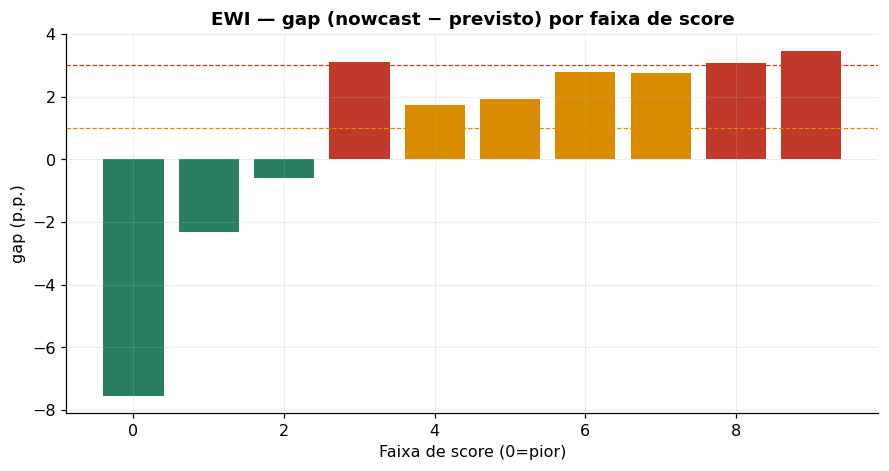

,pd_pred,pd_nowcast,n,flag,gap_pp
band,,,,,
0,0.288,0.212,1815,verde,-7.550000
1,0.181,0.158,1863,verde,-2.320000
2,0.139,0.133,1727,verde,-0.580000
3,0.113,0.144,1757,vermelho,3.120000
4,0.094,0.112,1800,âmbar,1.730000
5,0.080,0.100,1842,âmbar,1.930000
6,0.068,0.096,1790,âmbar,2.780000
7,0.058,0.085,1814,âmbar,2.740000
8,0.048,0.079,1809,vermelho,3.060000


In [12]:
ewi=fresh.groupby("band").agg(pd_pred=("pd_pred","mean"),pd_nowcast=("pd_nowcast","mean"),n=("id","size"))
ewi["gap"]=ewi.pd_nowcast-ewi.pd_pred
ewi["flag"]=pd.cut(ewi.gap,[-1,.01,.03,1],labels=["verde","âmbar","vermelho"])
cores={"verde":ACC2,"âmbar":AMB,"vermelho":ACC}

fig,ax=plt.subplots()
ax.bar(ewi.index,ewi.gap*100,color=[cores[f] for f in ewi.flag])
ax.axhline(1,color=AMB,ls="--",lw=.8); ax.axhline(3,color=ACC,ls="--",lw=.8)
ax.set_title("EWI — gap (nowcast − previsto) por faixa de score")
ax.set_xlabel("Faixa de score (0=pior)"); ax.set_ylabel("gap (p.p.)")
plt.tight_layout(); plt.show()
display(ewi.assign(gap_pp=(ewi.gap*100).round(2)).drop(columns="gap")
        .style.format({"pd_pred":"{:.3f}","pd_nowcast":"{:.3f}"}))

## 7. Síntese — cockpit de três eixos

| Camada | Sinal neste exemplo | Decisão |
|---|---|---|
| **Maturidade** (formal) | GINI/KS estáveis nas maduras | modelo "aprovado" no backtest oficial |
| **Safra** | observado descola do implícito nas safras 21–23 | originação deteriorando |
| **Calendário** (nowcast) | PD nowcast > PD previsto | carteira viva pior que o modelo prevê |
| **Convergência** | GINI final projetado dentro da banda | é nível, não ruído de imaturidade |
| **EWI** | 🔴 nas faixas boas | recalibrar / overlay de PD antes do próximo backtest |

O backtest tradicional sozinho aprovaria o modelo — porque só olha safras de 2024. As camadas coincidente e líder mostram que a carteira **viva** já está pior, e o EWI direciona a ação (recalibração / *overlay*) **um ano antes** do veredito formal.

### Como publicar
```bash
# executa e converte para HTML estático (GitHub Pages)
jupyter nbconvert --to notebook --execute backtest_nowcast.ipynb --output backtest_nowcast.ipynb
jupyter nbconvert --to html backtest_nowcast.ipynb --output index.html
```

> Próximos passos de produção: substituir a simulação por extração real (estado de atraso mensal por contrato, chave **CPF/CNPJ** para *leakage* de reestruturação), ponderar tudo em **saldo em risco**, adicionar **CSI por variável**, e plugar a matriz de transição num *job* mensal alimentando o EWI. Ver o plano de implementação em LaTeX que acompanha este notebook.
